包导入，matplotlib中文支持

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter, uniform_filter

# matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)


输入图片：mana.jpg（RGB → 灰度）
卷积核：运动模糊核
目标：使用盲去卷积算法从「模糊 + 噪声」图像中反卷积恢复原图

图像尺寸: (553, 526)  像素范围: [0.000, 1.000]


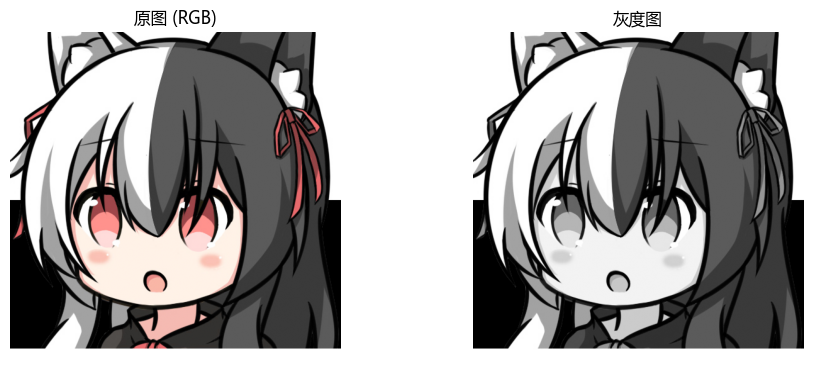

In [2]:
# 读取图片（RGB → 灰度）
# 注意：本环境 plt.imread 返回 [0, 255]，需先归一化到 [0, 1]
rgb = plt.imread('mana.jpg')
if rgb.max() > 1.0:
    rgb = rgb / 255.0
gray = rgb.mean(axis=2)
print(f'图像尺寸: {gray.shape}  像素范围: [{gray.min():.3f}, {gray.max():.3f}]')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(rgb); plt.title('原图 (RGB)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(gray, cmap='gray'); plt.title('灰度图'); plt.axis('off')
plt.tight_layout(); plt.show()


## 生成观测图像：运动模糊 + 高斯噪声

- 卷积核：运动模糊核（倾斜线段，长度 25、角度 30°）
- 观测：`observed = blur ⊛ kernel + noise`，噪声为高斯白噪声 σ=0.01
- 盲去卷积只知道「存在运动模糊」，**不知道核的具体形状**

In [3]:
def motion_blur_kernel(length, angle_deg):
    """生成运动模糊核：沿角度方向的倾斜线段，归一化后和为 1"""
    angle = np.deg2rad(angle_deg)
    t = np.linspace(-(length // 2), length // 2, length)
    kx = np.round(t * np.cos(angle)).astype(int)
    ky = np.round(t * np.sin(angle)).astype(int)
    kx -= kx.min()
    ky -= ky.min()
    kernel = np.zeros((ky.max() + 1, kx.max() + 1))
    kernel[ky, kx] = 1.0
    return kernel / kernel.sum()


真值核尺寸: (13, 21)


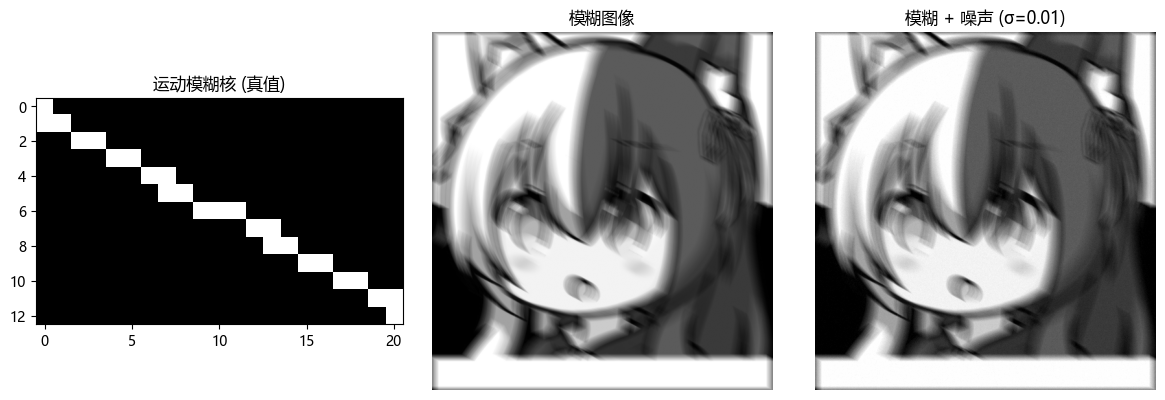

In [4]:
# 运动模糊核（真值，仅用于生成观测；盲去卷积时未知）
kernel_true = motion_blur_kernel(length=25, angle_deg=30)
print(f'真值核尺寸: {kernel_true.shape}')

# 模糊 + 高斯噪声 → 观测图像
blurred = fftconvolve(gray, kernel_true, mode='same')
noise_sigma = 0.01
observed = np.clip(blurred + np.random.normal(0, noise_sigma, gray.shape), 0, 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(kernel_true, cmap='gray'); plt.title('运动模糊核 (真值)')
plt.subplot(1, 3, 2); plt.imshow(blurred, cmap='gray'); plt.title('模糊图像'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(observed, cmap='gray'); plt.title(f'模糊 + 噪声 (σ={noise_sigma})'); plt.axis('off')
plt.tight_layout(); plt.show()


## 盲去卷积：Fergus 2006 经典三步流程

参考论文 *Removing Camera Shake from a Single Photograph*（Fergus et al., SIGGRAPH 2006），完整流程：

1. **预处理**：选择一块纹理丰富的图像块，降低计算量并保证核可辨识
2. **估计卷积核 K**：变分贝叶斯（稀疏先验）+ **coarse-to-fine** 多尺度策略，避免陷入局部最优
3. **重建清晰图像 L**：标准非盲去卷积（Richardson-Lucy）

> 盲去卷积只知道「存在运动模糊」，不知道核的具体形状，核的初值取 δ 脉冲。

In [5]:
def pad_kernel_fft(kernel, shape):
    """把核放置到图像尺寸中心，用于频域相乘"""
    padded = np.zeros(shape)
    y0 = (shape[0] - kernel.shape[0]) // 2
    x0 = (shape[1] - kernel.shape[1]) // 2
    padded[y0:y0 + kernel.shape[0], x0:x0 + kernel.shape[1]] = kernel
    return padded


In [6]:
def crop_kernel(kernel, size):
    """按支持域尺寸裁剪核（取中心）"""
    y0 = (kernel.shape[0] - size[0]) // 2
    x0 = (kernel.shape[1] - size[1]) // 2
    return kernel[y0:y0 + size[0], x0:x0 + size[1]]


### 第一步：预处理 — 选择图像块

- 核估计只需一块**纹理丰富**的局部区域（平坦区域对核不可辨识）
- 自动模式：滑动窗口统计梯度能量，取能量最大的块；也可手动指定中心
- 小图块大幅降低变分贝叶斯迭代的计算量

In [7]:
def select_patch(img, patch_size, center=None):
    """预处理：选择纹理丰富的图像块（Fergus 第一步）

    参数
    ----
    img : 灰度图像，[0, 1]
    patch_size : 块边长（正方形）
    center : (y, x)；为 None 时自动选择梯度能量最大的块

    返回
    ----
    patch : 选中的图像块
    (y0, x0) : 块在原图中的左上角坐标
    """
    size = min(patch_size, img.shape[0], img.shape[1])
    if center is not None:
        y0 = int(np.clip(center[0] - size // 2, 0, img.shape[0] - size))
        x0 = int(np.clip(center[1] - size // 2, 0, img.shape[1] - size))
        return img[y0:y0 + size, x0:x0 + size], (y0, x0)

    # 滑动窗口梯度能量（uniform_filter 实现快速窗口均值）
    gy, gx = np.gradient(img)
    energy = uniform_filter(gx ** 2 + gy ** 2, size=size, mode='constant')
    cy, cx = np.unravel_index(np.argmax(energy), energy.shape)
    y0 = int(np.clip(cy - size // 2, 0, img.shape[0] - size))
    x0 = int(np.clip(cx - size // 2, 0, img.shape[1] - size))
    return img[y0:y0 + size, x0:x0 + size], (y0, x0)


选择的图像块: (180, 180)，左上角 (y0=263, x0=71)


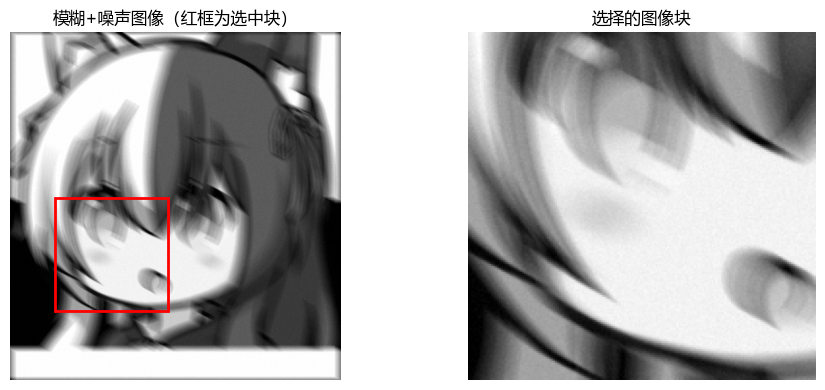

In [8]:
# 执行第一步：在【模糊图像】上自动选择梯度能量最大的 180×180 图像块
# （真实场景只有模糊图可用，选块必须在 observed 上进行）
patch, (y0, x0) = select_patch(observed, patch_size=180)
print(f'选择的图像块: {patch.shape}，左上角 (y0={y0}, x0={x0})')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(observed, cmap='gray'); plt.title('模糊+噪声图像（红框为选中块）')
rect = plt.Rectangle((x0, y0), patch.shape[1], patch.shape[0], fill=False, edgecolor='r', lw=2)
plt.gca().add_patch(rect); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(patch, cmap='gray'); plt.title('选择的图像块'); plt.axis('off')
plt.tight_layout(); plt.show()


### 第二步：变分贝叶斯估计卷积核 K（coarse-to-fine）

在**梯度域**建模：$g_x = k \circledast d_x$、$g_y = k \circledast d_y$（$d$ 为清晰图像梯度），EM 式交替更新：

- **E 步**：**shock 滤波**预测清晰边缘（恢复阶跃边缘）→ 软阈值收缩（重尾稀疏先验）
- **M 步**：最小二乘 + 正则估计核，施加非负（指数先验）与归一化 $\sum k = 1$，
  并**向上一尺度的核 $k_{\text{init}}$ 锚定**（指数衰减），使粗尺度核真正参与精化

**coarse-to-fine 策略**：对图像块建立高斯金字塔，从最粗尺度开始估计核，
每层将核上采样作为下一层初值，避免变分贝叶斯优化陷入局部最优。
（注意：若 M 步不做锚定，纯最小二乘直接解会在第一轮迭代丢弃初值，
导致 `num_levels` 参数完全不生效——各层等价于独立从 δ 估计。）

In [9]:
def build_gaussian_pyramid(img, num_levels):
    """高斯金字塔：每层先高斯模糊再降采样 2 倍（coarse-to-fine 用）"""
    pyramid = [img]
    current = img
    for _ in range(num_levels - 1):
        current = gaussian_filter(current, sigma=1.0)
        current = current[::2, ::2]
        pyramid.append(current)
    return pyramid


In [10]:
def soft_threshold(x, t):
    """软阈值收缩：重尾稀疏先验（混合高斯）对应的近端算子，用于 E 步去噪"""
    return np.sign(x) * np.maximum(np.abs(x) - t, 0)


In [11]:
def shock_filter(img, iterations=10, dt=0.1):
    """shock 滤波器：沿梯度方向把边缘锐化成阶跃（E 步边缘预测）"""
    u = img.copy()
    for _ in range(iterations):
        uy, ux = np.gradient(u)
        norm = np.hypot(ux, uy) + 1e-12
        nx, ny = ux / norm, uy / norm
        uxx = np.gradient(ux, axis=1)
        uxy = np.gradient(ux, axis=0)
        uyy = np.gradient(uy, axis=0)
        l_eta_eta = nx ** 2 * uxx + 2 * nx * ny * uxy + ny ** 2 * uyy
        u = u - dt * np.sign(l_eta_eta) * norm
    return u


In [12]:
def vb_estimate_kernel(patch, k_init, num_iters=30, lambda_e=1e-3, lambda_k=1e-2,
                       tau=1e-3, shock_iters=5, k_anchor=0.7):
    """单尺度变分贝叶斯估计卷积核（梯度域 EM 交替）

    参数
    ----
    patch : 模糊图像块
    k_init : 核初值（最粗层为 δ，其余层为上一尺度上采样结果）
    num_iters : EM 迭代次数
    lambda_e : 潜像 Wiener 更新的正则强度
    lambda_k : M 步核估计的正则强度
    tau : E 步软阈值（稀疏先验强度）
    shock_iters : shock 滤波迭代次数
    k_anchor : M 步向 k_init 锚定比例（0~1，指数衰减）

    返回
    ----
    k : 估计核（非负、和为 1）

    注意：若 k_anchor = 0，M 步为纯最小二乘直接解，第一轮迭代即把
    k_init 完全覆盖丢弃，coarse-to-fine 的上采样初值将完全不生效。
    """
    b = patch
    B = np.fft.fft2(b)
    Gx = np.fft.fft2(np.gradient(b, axis=1))
    Gy = np.fft.fft2(np.gradient(b, axis=0))
    k = k_init.copy()
    x = b.copy()
    for it in range(num_iters):
        # ---- E 步：shock 滤波预测清晰边缘 + 软阈值收缩 ----
        xs = shock_filter(x, iterations=shock_iters)
        dx = soft_threshold(np.gradient(xs, axis=1), tau)
        dy = soft_threshold(np.gradient(xs, axis=0), tau)
        # ---- M 步：最小二乘估计核 + 向 k_init 锚定 ----
        Dx = np.fft.fft2(dx)
        Dy = np.fft.fft2(dy)
        num = np.conj(Dx) * Gx + np.conj(Dy) * Gy
        den = np.abs(Dx) ** 2 + np.abs(Dy) ** 2 + lambda_k
        k_ls = crop_kernel(np.real(np.fft.ifft2(num / den)), k_init.shape)
        k_ls = np.clip(k_ls, 0, None)   # 非负约束（指数先验）
        k_ls /= k_ls.sum()              # 能量归一化
        alpha = k_anchor * (0.5 ** (it // 5))   # 前几轮强锚定，之后衰减
        k = (1 - alpha) * k_ls + alpha * k_init
        k = np.clip(k, 0, None)
        k /= k.sum()
        # ---- 更新潜像 x（Wiener 反卷积）供下一轮 E 步 ----
        K = np.fft.fft2(pad_kernel_fft(k, patch.shape))
        X = np.conj(K) * B / (np.abs(K) ** 2 + lambda_e)
        x = np.real(np.fft.ifft2(X))
        x = np.clip(x, 0, 1)
    return k


In [13]:
def upsample_kernel(k, factor=2):
    """核上采样 factor 倍（零插值 + 高斯平滑），coarse-to-fine 层间初始化用"""
    h, w = k.shape
    big = np.zeros((h * factor, w * factor))
    big[::factor, ::factor] = k
    big = gaussian_filter(big, sigma=0.6)
    return big / big.sum()


In [14]:
def fit_kernel(k, size):
    """把核居中放入指定尺寸：过大则裁剪，过小则补零"""
    h, w = k.shape
    if h > size[0]:
        y0 = (h - size[0]) // 2
        k = k[y0:y0 + size[0]]
    if w > size[1]:
        x0 = (w - size[1]) // 2
        k = k[:, x0:x0 + size[1]]
    out = np.zeros(size)
    y0 = (size[0] - k.shape[0]) // 2
    x0 = (size[1] - k.shape[1]) // 2
    out[y0:y0 + k.shape[0], x0:x0 + k.shape[1]] = k
    return out


In [15]:
def estimate_kernel_coarse_to_fine(patch, kernel_size, num_levels=2, num_iters=30, **kwargs):
    """coarse-to-fine 策略估计卷积核（Fergus 第二步）

    参数
    ----
    patch : 模糊图像块
    kernel_size : 最终核边长（正方形）
    num_levels : 金字塔层数（每层图像与核尺寸等比缩小 2 倍；
                 实测 2 层最优，过深时小图块估计的粗核会污染细层）
    num_iters : 每层 EM 迭代次数
    **kwargs : 传给 vb_estimate_kernel 的其余参数（如 k_anchor）

    返回
    ----
    k : 估计核（尺寸 kernel_size × kernel_size）
    """
    pyramid = build_gaussian_pyramid(patch, num_levels)
    # 每层核尺寸随分辨率等比缩小（取奇数）
    sizes = [max(3, int(round(kernel_size / (2 ** level))) | 1) for level in range(num_levels)]
    k = None
    for level in range(num_levels - 1, -1, -1):   # 从最粗尺度到最细
        size = (sizes[level], sizes[level])
        if k is None:
            k = np.zeros(size)
            k[size[0] // 2, size[1] // 2] = 1.0   # 最粗层初值：δ 脉冲
        else:
            k = fit_kernel(upsample_kernel(k, 2), size)   # 上采样上一尺度核作初值
        # 每层估计：k_init 通过 k_anchor 锚定真正参与精化
        k = vb_estimate_kernel(pyramid[level], k, num_iters, **kwargs)
    return k


估计核尺寸: (25, 25)  核和: 1.0000


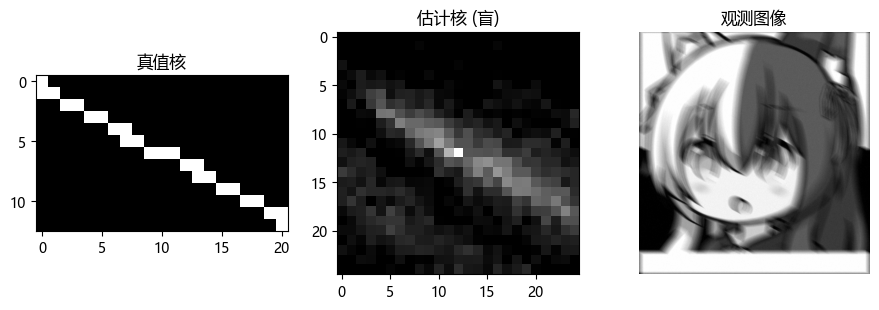

In [16]:
# 执行第二步：coarse-to-fine 变分贝叶斯估计核（2 层金字塔，k_init 锚定精化）
k_est = estimate_kernel_coarse_to_fine(patch, kernel_size=25, num_levels=2, num_iters=30, k_anchor=0.7)
print(f'估计核尺寸: {k_est.shape}  核和: {k_est.sum():.4f}')

plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1); plt.imshow(kernel_true, cmap='gray'); plt.title('真值核')
plt.subplot(1, 3, 2); plt.imshow(k_est, cmap='gray'); plt.title('估计核 (盲)')
plt.subplot(1, 3, 3); plt.imshow(observed, cmap='gray'); plt.title('观测图像'); plt.axis('off')
plt.tight_layout(); plt.show()


### 第三步：非盲去卷积重建清晰图像 L（TV 全变差正则化）

- 核已由第二步估计得到（固定不再更新）
- 使用**全变差（TV）正则化**反卷积（Chambolle-Pock 原始-对偶算法）：
$$\min_x \frac{1}{2}\Vert Ax - y \Vert_2^2 + \lambda \sum_{ij}\sqrt{(\nabla_x x)^2 + (\nabla_y x)^2}$$
- TV 保留边缘同时抑制噪声，比 Richardson-Lucy 对噪声更稳健

In [17]:
def grad(x):
    """前向差分梯度，返回 (gx, gy)，边界外视为 0"""
    gx = np.zeros_like(x)
    gy = np.zeros_like(x)
    gx[:, :-1] = x[:, 1:] - x[:, :-1]   # x 方向（水平）
    gy[:-1, :] = x[1:, :] - x[:-1, :]   # y 方向（垂直）
    return gx, gy


In [18]:
def div(px, py):
    """梯度算子的负伴随（散度）：<∇x, p> = <x, -div p>"""
    out = np.zeros_like(px)
    out[1:, :] += px[:-1, :] - px[1:, :]
    out[0, :] += -px[0, :]
    out[:, 1:] += py[:, :-1] - py[:, 1:]
    out[:, 0] += -py[:, 0]
    return out


In [19]:
def deconv_tv(y, h, lam, num_iter=200):
    """全变差（TV）正则化反卷积（Chambolle-Pock 原始-对偶算法）

    min_x 1/2||Ax - y||^2 + λ·TV(x)，TV = Σ sqrt((∇x_x)² + (∇x_y)²)
    卷积算子 A 及其伴随 A*（翻转核）都用 FFT 实现；数据已归一化到 [0,1]。
    """
    h_flip = h[::-1, ::-1]
    # 步长：||K||² ≤ ||A||² + ||∇||² ≤ 1 + 8 = 9，取 στ < 1/9
    sigma = tau = 0.99 / np.sqrt(9.0)
    theta = 1.0

    x_hat = y.copy()
    xbar = x_hat.copy()
    pA = np.zeros_like(y)     # 保真项对偶变量
    pqx = np.zeros_like(y)    # TV 对偶变量（水平）
    pqy = np.zeros_like(y)    # TV 对偶变量（垂直）

    for _ in range(num_iter):
        # ---- 对偶更新 ----
        Axbar = fftconvolve(xbar, h, mode='same')
        gxbar = grad(xbar)
        # 保真项：prox_{σf*}(v) = (v - σy)/(1+σ)
        pA = (pA + sigma * (Axbar - y)) / (1 + sigma)
        # TV：投影到每个像素 ||q||₂ ≤ λ
        vqx = pqx + sigma * gxbar[0]
        vqy = pqy + sigma * gxbar[1]
        nrm = np.sqrt(vqx ** 2 + vqy ** 2)
        scale = np.minimum(1.0, lam / (nrm + 1e-12))
        pqx = vqx * scale
        pqy = vqy * scale

        # ---- 原始更新：x ← x - τ(A* pA - div q) ----
        Apx = fftconvolve(pA, h_flip, mode='same')
        x_new = x_hat - tau * (Apx - div(pqx, pqy))

        # ---- 外推 ----
        xbar = x_new + theta * (x_new - x_hat)
        x_hat = x_new

    return x_hat


In [20]:
# 执行第三步：用估计核做 TV 非盲反卷积，重建清晰图像 L
L = np.clip(deconv_tv(observed, k_est, lam=1e-5, num_iter=200), 0, 1)
print(f'重建完成: {L.shape}')


重建完成: (553, 526)


In [21]:
def compute_psnr(img, ref, data_range=1.0):
    """峰值信噪比 PSNR（dB）"""
    mse = np.mean((img - ref) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(data_range ** 2 / mse)


In [22]:
def compute_ssim(img, ref, data_range=1.0, k1=0.01, k2=0.03):
    """结构相似性 SSIM（全局单值近似，C1/C2 取 skimage 同款默认）"""
    c1 = (k1 * data_range) ** 2
    c2 = (k2 * data_range) ** 2
    mu_x, mu_y = img.mean(), ref.mean()
    var_x = img.var()
    var_y = ref.var()
    cov = np.mean((img - mu_x) * (ref - mu_y))
    return ((2 * mu_x * mu_y + c1) * (2 * cov + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2))


### 结果评估（PSNR / SSIM）

模糊+噪声观测 : PSNR = 15.11 dB, SSIM = 0.8817
盲去卷积恢复 : PSNR = 16.58 dB, SSIM = 0.9223


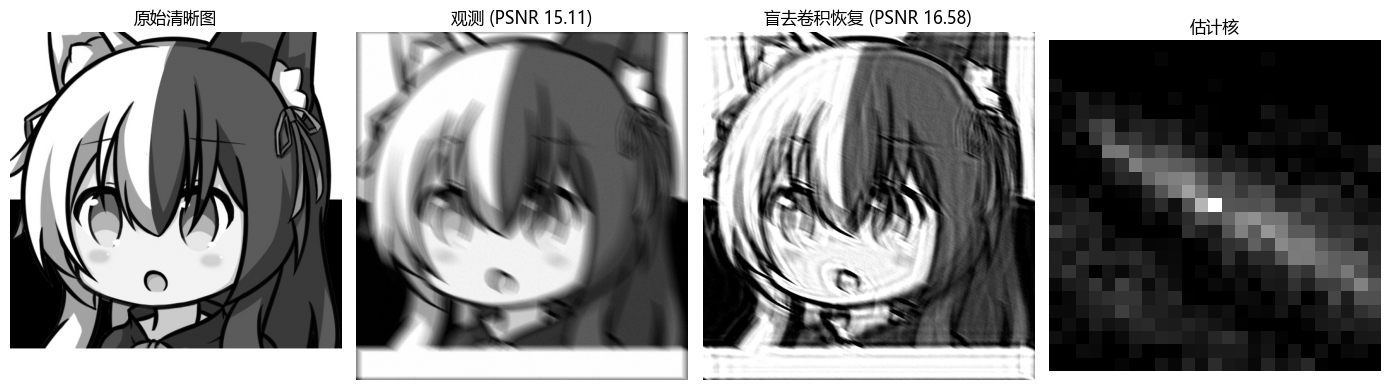

In [23]:
# 对比观测与重建结果
p_obs = compute_psnr(observed, gray)
s_obs = compute_ssim(observed, gray)
p_rec = compute_psnr(L, gray)
s_rec = compute_ssim(L, gray)
print(f'模糊+噪声观测 : PSNR = {p_obs:.2f} dB, SSIM = {s_obs:.4f}')
print(f'盲去卷积恢复 : PSNR = {p_rec:.2f} dB, SSIM = {s_rec:.4f}')

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1); plt.imshow(gray, cmap='gray'); plt.title('原始清晰图'); plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(observed, cmap='gray'); plt.title(f'观测 (PSNR {p_obs:.2f})'); plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(L, cmap='gray'); plt.title(f'盲去卷积恢复 (PSNR {p_rec:.2f})'); plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(k_est, cmap='gray'); plt.title('估计核'); plt.axis('off')
plt.tight_layout(); plt.show()
